In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors, cm
import networkx as nx
from causallearn.search.ConstraintBased.PC import pc
import contextlib
from io import StringIO
import re
from pathlib import Path
import os

In [2]:
project_root = Path('./').resolve().parents[2]
print(project_root)
base_dir = os.path.join(project_root, 'mastersResearch_Jun_Sept2025', 'causalDiscovery_J', 'motivationAnalysis')
print(base_dir)
meta_file = os.path.join(base_dir, 'motivation_dag_1.csv')
data = pd.read_csv(meta_file).to_numpy()

/Users/joshparchure/pyspocClone5Aug/py-spoc/working_analyses
/Users/joshparchure/pyspocClone5Aug/py-spoc/working_analyses/mastersResearch_Jun_Sept2025/causalDiscovery_J/motivationAnalysis


  0%|          | 0/3 [00:00<?, ?it/s]

Found 12 p-values
[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.491804, 0.618612, 0.491804, 0.0, 0.618612, 0.0]


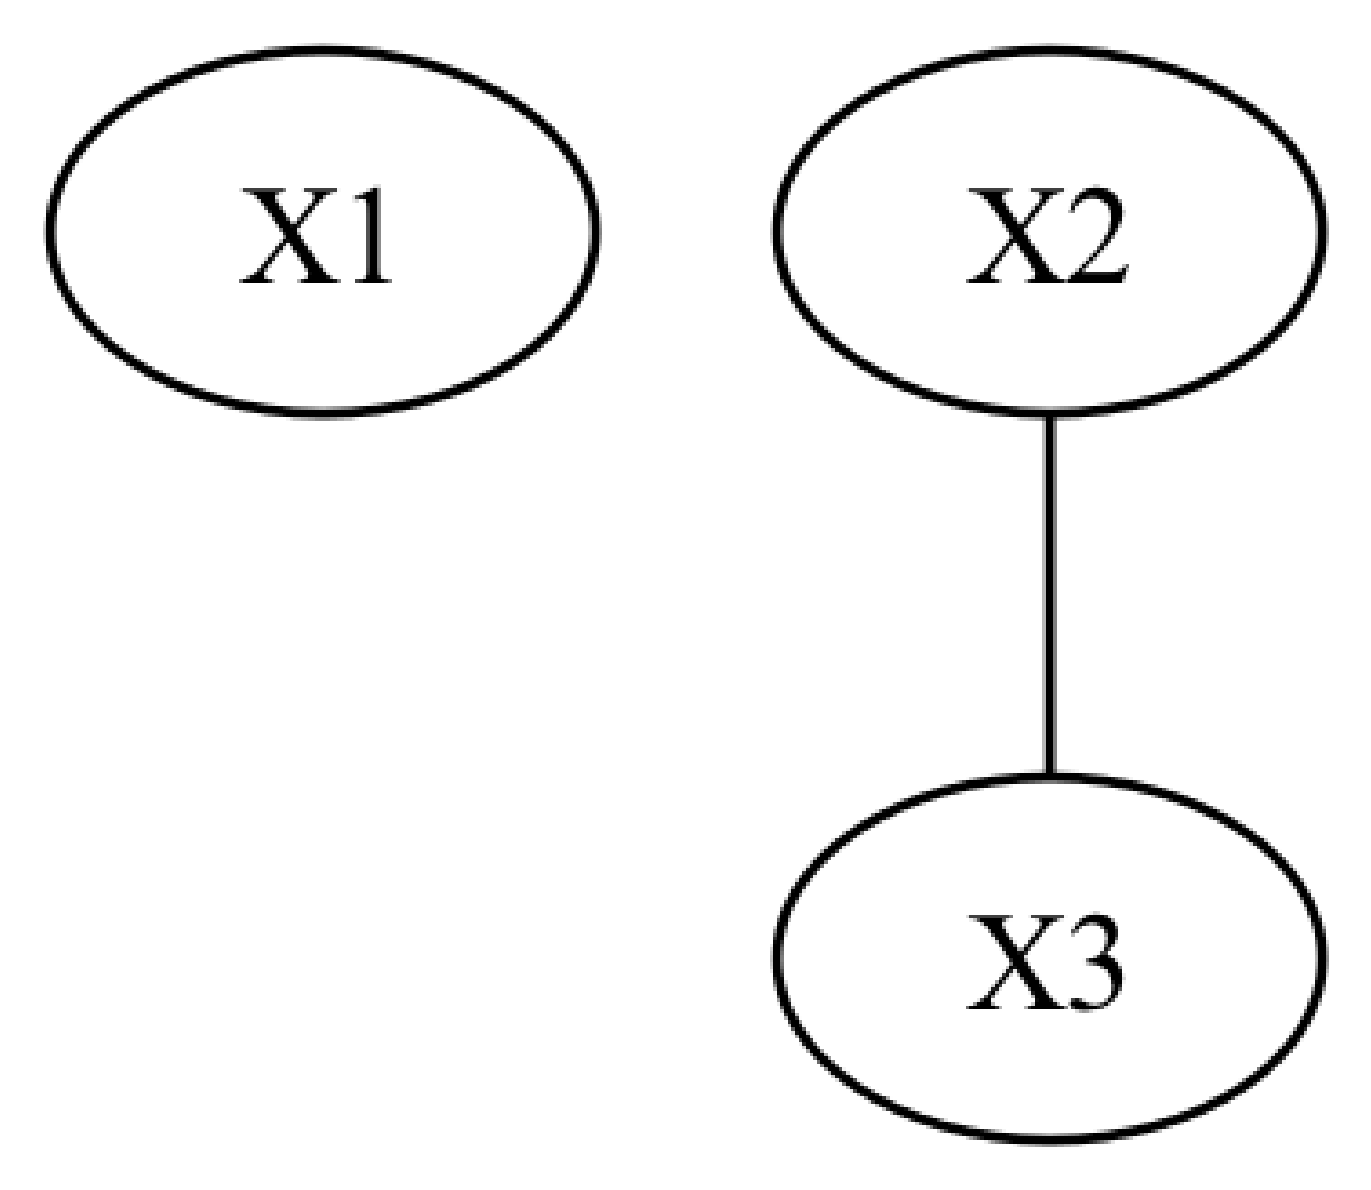

In [3]:
with contextlib.redirect_stdout(StringIO()) as captured:
    cg = pc(data, alpha=0.05, indep_test='fisherz', verbose=True)

verbose_output = captured.getvalue()
p_values = re.findall(r'p-value\s+([\d\.e-]+)', verbose_output)
p_values = [float(p) for p in p_values]

print(f"Found {len(p_values)} p-values")
print(p_values)

cg.draw_pydot_graph()